In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [6]:
df=pd.read_csv("C:\\Users\\Hp\\OneDrive\\Desktop\\ML_Project\\notebook\\data\\stud.csv")

In [7]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
X=df.drop(columns=['math_score'])

In [11]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [10]:
y=df['math_score']

In [12]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)   
    ]
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_21680\1503520814.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features=X.select_dtypes(include='object').columns


In [13]:
X=preprocessor.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [17]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [20]:
models={
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "SVR": SVR(),
    "XGB Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False)
}
model_list=[]
r2_list=[]

for i in range(len(models)):
    model=list(models.values())[i]
    model.fit(X_train, y_train)

    y_test_pred=model.predict(X_test)
    y_train_pred=model.predict(X_train)

    model_train_mae,model_train_mse,model_train_rmse,model_train_r2=evaluate_model(y_train, y_train_pred)
    model_test_mae,model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test, y_test_pred) 

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set")
    print("- Root Mean sqaured Error: {: 4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {: 4f}".format(model_train_mae))
    print("- R2 Score: {: 4f}".format(model_train_r2))

    print("---------------------------------------------------------")

    print("Model performance for testing set")
    print("- Root Mean sqaured Error: {: 4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {: 4f}".format(model_test_mae))
    print("- R2 Score: {: 4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*35)
    print("\n")

Linear Regression
Model performance for training set
- Root Mean sqaured Error:  5.323051
- Mean Absolute Error:  4.266712
- R2 Score:  0.874317
---------------------------------------------------------
Model performance for testing set
- Root Mean sqaured Error:  5.393994
- Mean Absolute Error:  4.214763
- R2 Score:  0.880433


Ridge Regression
Model performance for training set
- Root Mean sqaured Error:  5.323325
- Mean Absolute Error:  4.264988
- R2 Score:  0.874304
---------------------------------------------------------
Model performance for testing set
- Root Mean sqaured Error:  5.390387
- Mean Absolute Error:  4.211101
- R2 Score:  0.880593


Lasso Regression
Model performance for training set
- Root Mean sqaured Error:  6.593816
- Mean Absolute Error:  5.206303
- R2 Score:  0.807146
---------------------------------------------------------
Model performance for testing set
- Root Mean sqaured Error:  6.519695
- Mean Absolute Error:  5.157882
- R2 Score:  0.825320


KNN Regre

In [21]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model", "R2 Score"]).sort_values(by="R2 Score", ascending=False  )

,Model,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
6,AdaBoost Regressor,0.853423
9,CatBoost Regressor,0.851632
5,Random Forest Regressor,0.849733
8,XGB Regressor,0.827797
2,Lasso Regression,0.825320
3,KNN Regressor,0.783813
4,Decision Tree Regressor,0.744656
7,SVR,0.728600


In [22]:
#Linear Regression
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train, y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 88.04


Text(0, 0.5, 'Predicted Values')

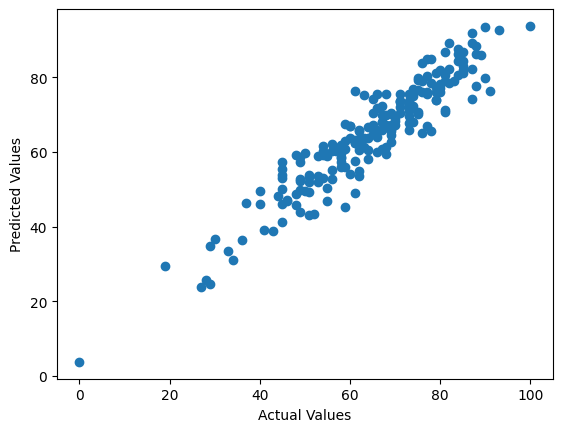

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")     
plt.ylabel("Predicted Values")

<Axes: xlabel='math_score'>

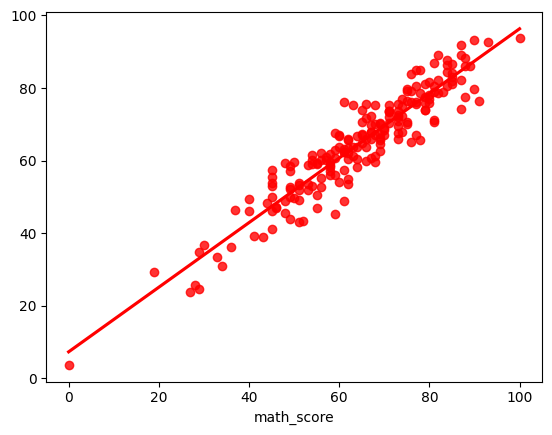

In [24]:
sns.regplot(x=y_test, y=y_pred, ci=None, color="red")

In [25]:
#diff bet actual and predicted values
pred_df=pd.DataFrame({"Actual Values": y_test, "Predicted Values": y_pred})
pred_df

,Actual Values,Predicted Values
521,91,76.387970
737,53,58.885970
740,80,76.990265
660,74,76.851804
411,84,87.627378
...,...,...
408,52,43.409149
332,62,62.152214
208,74,67.888395
613,65,67.022287
